## Task 1: Data Loading and Initial Inspection

In [1]:
# Download the dataset
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

--2026-05-19 13:05:33--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv.1’

titanic.csv.1       100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2026-05-19 13:05:33 (3.90 MB/s) - ‘titanic.csv.1’ saved [60302/60302]



In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('titanic.csv')

# Display the first 5 rows
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check the data types of all columns
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
# Get descriptive statistics of the numerical columns
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Identify the total number of missing values for each column
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Task 2: Handling Missing Values

### Cabin Column

In [16]:
# Calculate the percentage of missing values in the Cabin column
missing_cabin_percentage = (df['Cabin'].isnull().sum() / len(df)) * 100
print(f"Percentage of missing values in 'Cabin' column: {missing_cabin_percentage:.2f}%")


df = df.drop('Cabin', axis=1)
print("\n'Cabin' column dropped due to a high percentage of missing values.")

KeyError: 'Cabin'

### Embarked Column

In [7]:
# Find the most frequent port of embarkation (the mode)
most_frequent_embarked = df['Embarked'].mode()[0]
print(f"Most frequent port of embarkation: {most_frequent_embarked}")

# Impute the missing values in the Embarked column with the mode
df['Embarked'].fillna(most_frequent_embarked, inplace=True)
print("Missing values in 'Embarked' column imputed with the mode.")

Most frequent port of embarkation: S
Missing values in 'Embarked' column imputed with the mode.


/tmp/ipykernel_5480/2883543627.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(most_frequent_embarked, inplace=True)


### Age Column

In [8]:
# Impute the missing values in the Age column with the median age
median_age = df['Age'].median()
print(f"Median age: {median_age}")

df['Age'].fillna(median_age, inplace=True)
print("Missing values in 'Age' column imputed with the median.")

# Verify that missing values have been handled
print("\nUpdated missing values count after imputation:")
display(df.isnull().sum())

Median age: 28.0
Missing values in 'Age' column imputed with the median.

Updated missing values count after imputation:


/tmp/ipykernel_5480/2970086424.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Task 3: Univariate Analysis

### Survival Rate

Overall Survival Rate: 38.38%


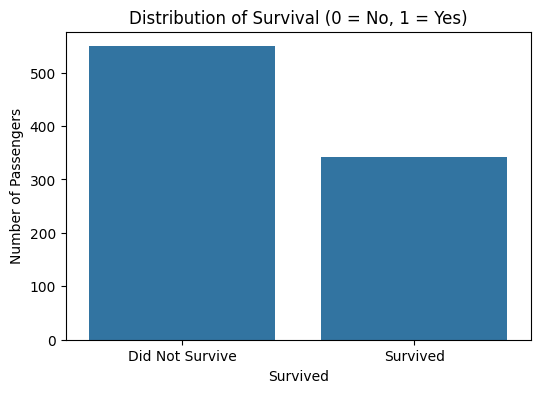

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the overall survival rate
survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

# Visualize the distribution of the Survived variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df)
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Did Not Survive', 'Survived'])
plt.show()

### Passenger Class (Pclass)

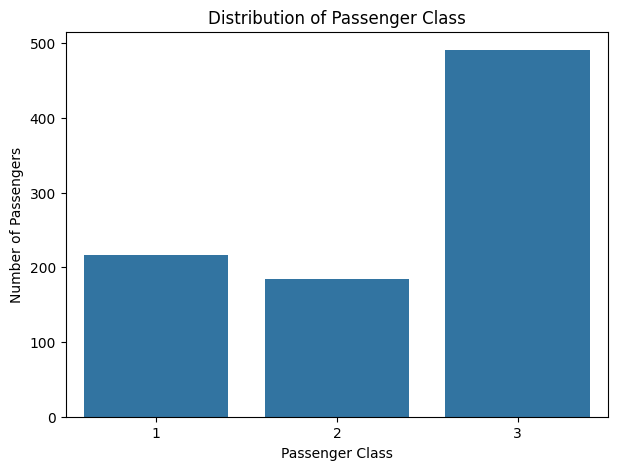

The class with the most passengers was: 3 (491 passengers)


In [10]:
# Visualize the distribution of Pclass
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', data=df)
plt.title('Distribution of Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

# Identify which class had the most passengers
most_passengers_pclass = df['Pclass'].value_counts().idxmax()
print(f"The class with the most passengers was: {most_passengers_pclass} ({df['Pclass'].value_counts().max()} passengers)")

### Age Distribution

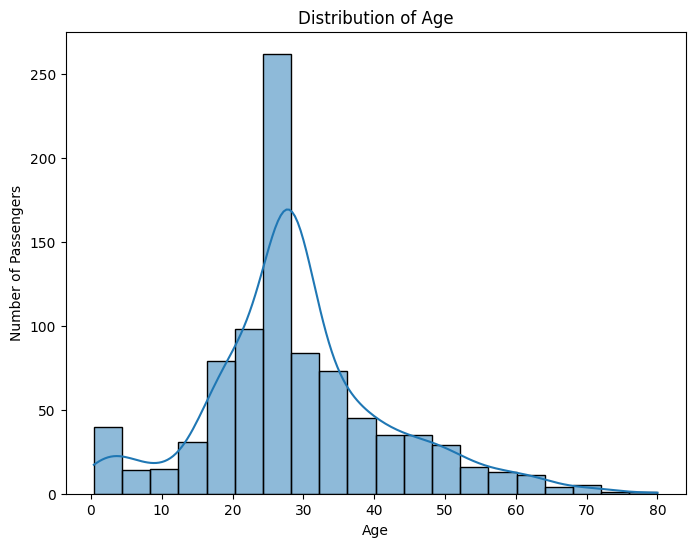

In [11]:
# Plot a histogram of the Age column
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

## Task 4: Bivariate and Multivariate Analysis

### Survival by Class (Pclass)

Survival Rate by Pclass:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


/tmp/ipykernel_5480/2366475531.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ci=None)


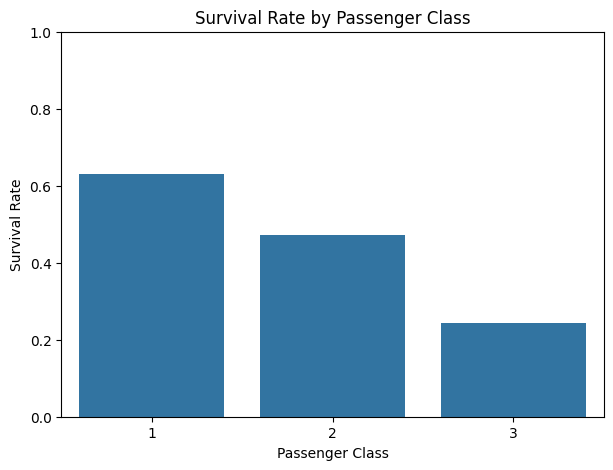


Observation: There is a clear correlation between ticket class and survival probability. Passengers in 1st class had a significantly higher survival rate compared to those in 2nd and 3rd class.


In [12]:
# Calculate survival rate for each Pclass
survival_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100
print("Survival Rate by Pclass:")
print(survival_by_pclass)

# Visualize the survival rate for each Pclass
plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=df, ci=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

# Question: Is there a clear correlation between ticket class and survival probability?
print("\nObservation: There is a clear correlation between ticket class and survival probability. Passengers in 1st class had a significantly higher survival rate compared to those in 2nd and 3rd class.")

### Survival by Age

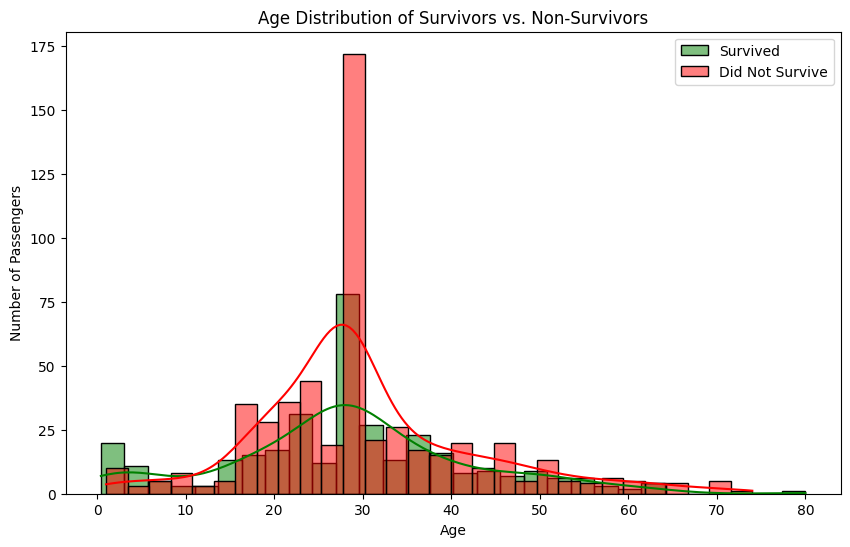


Observation: The plot suggests that children (especially very young ones) had a higher chance of survival. There also appears to be a slight increase in survival rate for some older age groups, although this is less pronounced than for children. Generally, young and middle-aged adults had a lower survival probability.


In [17]:
# Plot and compare the age distribution of survivors vs. non-survivors
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Survived'] == 1]['Age'], bins=30, kde=True, color='green', label='Survived')
sns.histplot(df[df['Survived'] == 0]['Age'], bins=30, kde=True, color='red', label='Did Not Survive')
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()


print("\nObservation: The plot suggests that children (especially very young ones) had a higher chance of survival. There also appears to be a slight increase in survival rate for some older age groups, although this is less pronounced than for children. Generally, young and middle-aged adults had a lower survival probability.")

### Survival by Port of Embarkation (Embarked)

Survival Rate by Embarked Port:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


/tmp/ipykernel_5480/3023027986.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=df, ci=None)


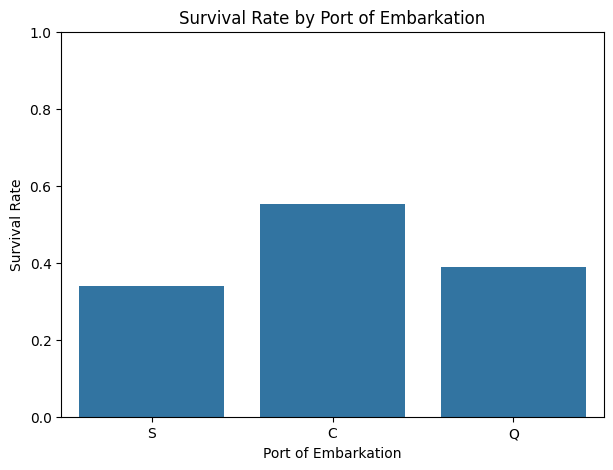

In [14]:
# Calculate survival rate for each Embarked port
survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100
print("Survival Rate by Embarked Port:")
print(survival_by_embarked)

# Visualize the survival rate for each Embarked port
plt.figure(figsize=(7, 5))
sns.barplot(x='Embarked', y='Survived', data=df, ci=None)
plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

## Task 5: Conclusion and Insights

Based on the Exploratory Data Analysis, several factors appear to significantly influence survival on the Titanic. The **passenger class (Pclass)** stands out as a strong predictor, with 1st class passengers having a substantially higher survival rate compared to those in 2nd and 3rd class. **Age** also played a crucial role, as very young children demonstrated a higher chance of survival, likely due to 'women and children first' protocols. Finally, the **port of embarkation (Embarked)** showed a notable difference, with passengers embarking from Cherbourg (C) having a higher survival rate, possibly correlating with the economic status of passengers from that port, which in turn might relate to their Pclass. These three features—Pclass, Age, and Embarked—emerge as the top predictors of survival.